In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
# DEVICE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# PATHS + TRANSFORMS

DATA_DIR = "../data/raw/fer2013"
test_dir = os.path.join(DATA_DIR, "test")

test_transform = basic_trasform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

print("Test dir exists:", os.path.exists(test_dir))

Test dir exists: True


In [4]:
# DATASETS + DATALOADER

test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)
classes = test_dataset.classes
num_classes = len(classes)

BATCH_SIZE = 64
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Test samples:", len(test_dataset))
print("Classes:", classes)

Test samples: 7178
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
# CNN

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [6]:
# LOAD SAVED MODEL WEIGHTS

model = CNN(num_classes=num_classes).to(device)

# MODEL_PATH = "../models/cnn_best.pt"
MODEL_PATH = "../models/improved_cnn_best.pt"
assert os.path.exists(MODEL_PATH), f"Model not found at {MODEL_PATH}"

state = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state)
model.eval()

print("Loaded model weights from:", MODEL_PATH)


RuntimeError: Error(s) in loading state_dict for CNN:
	Missing key(s) in state_dict: "features.6.weight", "features.6.bias", "classifier.4.weight", "classifier.4.bias". 
	Unexpected key(s) in state_dict: "features.9.weight", "features.9.bias", "features.9.running_mean", "features.9.running_var", "features.9.num_batches_tracked", "features.11.weight", "features.11.bias", "features.12.weight", "features.12.bias", "features.12.running_mean", "features.12.running_var", "features.12.num_batches_tracked", "features.16.weight", "features.16.bias", "features.17.weight", "features.17.bias", "features.17.running_mean", "features.17.running_var", "features.17.num_batches_tracked", "features.19.weight", "features.19.bias", "features.20.weight", "features.20.bias", "features.20.running_mean", "features.20.running_var", "features.20.num_batches_tracked", "features.1.weight", "features.1.bias", "features.1.running_mean", "features.1.running_var", "features.1.num_batches_tracked", "features.4.weight",

In [ ]:
# INFERENCE ON TEST SET

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Collected predictions:", y_pred.shape, "Ground truth:", y_true.shape)
print("Test accuracy:", (y_pred == y_true).mean())

KeyboardInterrupt: 

In [ ]:
# REPORT

report = classification_report(
    y_true, y_pred,
    target_names=classes,
    digits=4
)
print(report)

              precision    recall  f1-score   support

       angry     0.5412    0.4322    0.4806       958
     disgust     0.6279    0.2432    0.3506       111
        fear     0.4085    0.3398    0.3710      1024
       happy     0.7739    0.8489    0.8097      1774
     neutral     0.5623    0.5637    0.5630      1233
         sad     0.4362    0.5180    0.4736      1247
    surprise     0.7170    0.7377    0.7272       831

    accuracy                         0.5919      7178
   macro avg     0.5810    0.5262    0.5394      7178
weighted avg     0.5868    0.5919    0.5858      7178



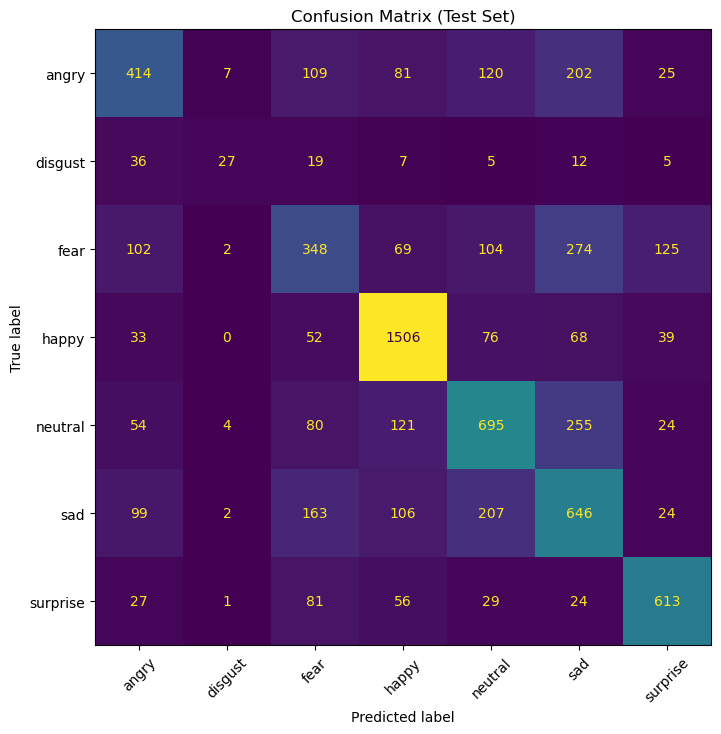

In [ ]:
# CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix (Test Set)")
plt.show()

In [ ]:
# PER CLASS ACCURACY

per_class_acc = cm.diagonal() / cm.sum(axis=1)

for i, cls in enumerate(classes):
    print(f"{cls:>8}: {per_class_acc[i]:.4f}")

   angry: 0.4322
 disgust: 0.2432
    fear: 0.3398
   happy: 0.8489
 neutral: 0.5637
     sad: 0.5180
surprise: 0.7377


In [ ]:
# MISCLASSIFIED EXAMPLES

def denormalise(img_tensor, mean=0.5, std=0.5):
    # img_tensor shape (1, H, W)
    return img_tensor * std + mean

mis_id = np.where(y_pred != y_true)[0]
print("Misclassified samples:", len(mis_id))

Misclassified samples: 2929


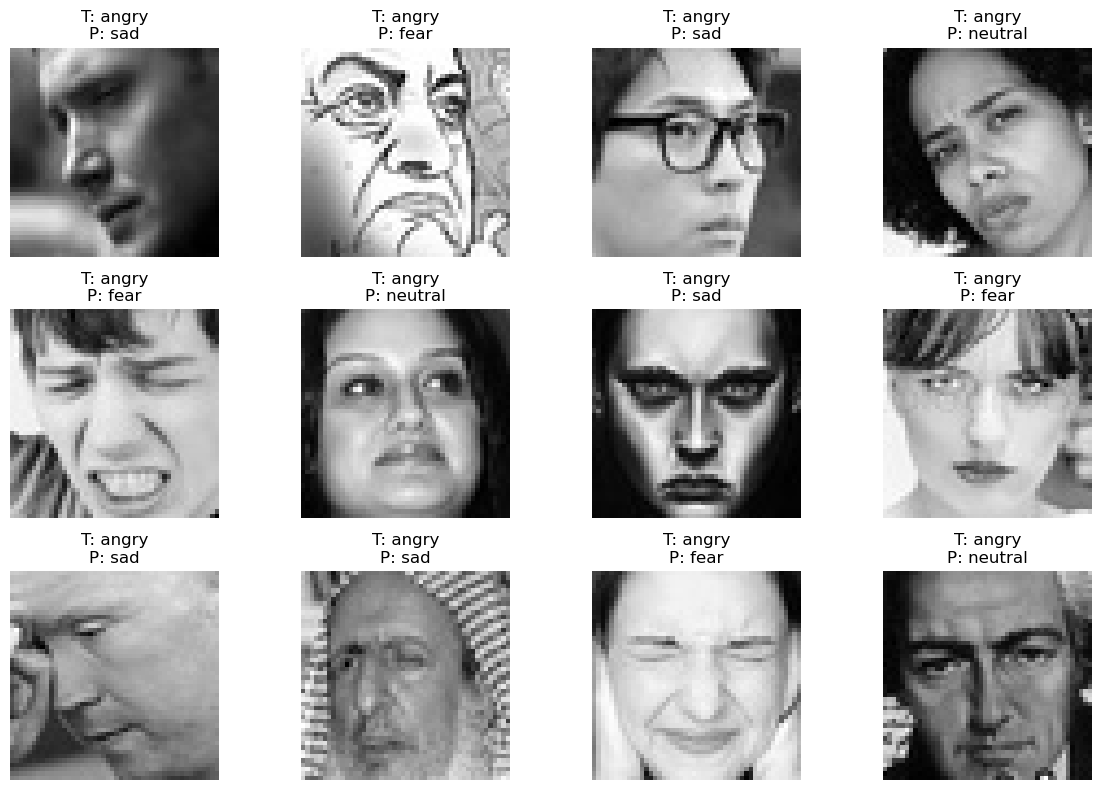

In [ ]:
# PLOTTING MISCLASSIFIED

def show_misclassified(dataset, indices, y_true, y_pred, classes, n=12):
    n = min(n, len(indices))
    fig, axes = plt.subplots(3, 4, figsize=(12, 8))
    axes = axes.flatten()

    for i in range(n):
        idx = indices[i]
        img, _ = dataset[idx]  # label already in y_true
        img = denormalise(img).squeeze().numpy()

        true_label = classes[y_true[idx]]
        pred_label = classes[y_pred[idx]]

        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f"T: {true_label}\nP: {pred_label}")
        axes[i].axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

show_misclassified(test_dataset, mis_id, y_true, y_pred, classes, n=12)